# Customer Segmentation with RFM + K-Means
**AI Engineering Track — Arabian Academy**

This notebook builds customer personas from one year of raw retail transaction data using RFM
(Recency, Frequency, Monetary) feature engineering and K-Means clustering.

**Workflow:** raw transactions → RFM table → scaling → k selection (elbow + silhouette) → K-Means fit → PCA visualization → persona naming.

## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

plt.rcParams['figure.figsize'] = (7, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

df = pd.read_csv('retail_transactions_segmentation.csv', parse_dates=['transaction_date'])
print(f"Shape: {df.shape}")
print(f"Unique customers: {df['customer_id'].nunique()}")
print(f"Date range: {df['transaction_date'].min().date()} to {df['transaction_date'].max().date()}")
df.head()

Shape: (3663, 4)
Unique customers: 300
Date range: 2024-01-01 to 2024-12-30


,customer_id,transaction_date,amount,product_category
0,5206,2024-01-31,162.65,Fashion
1,5153,2024-07-03,389.85,Fashion
2,5102,2024-11-13,453.72,Home & Living
3,5073,2024-03-11,824.74,Electronics
4,5097,2024-12-28,181.74,Sports


In [2]:
df.info()
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 3663 entries, 0 to 3662
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       3663 non-null   int64         
 1   transaction_date  3663 non-null   datetime64[us]
 2   amount            3663 non-null   float64       
 3   product_category  3663 non-null   str           
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 114.6 KB


,customer_id,transaction_date,amount,product_category
count,3663.000000,3663,3663.000000,3663
unique,NaN,NaN,NaN,6
top,NaN,NaN,NaN,Groceries
freq,NaN,NaN,NaN,640
mean,5147.309036,2024-07-22 09:56:45.405405,513.028376,NaN
min,5001.000000,2024-01-01 00:00:00,5.000000,NaN
25%,5073.000000,2024-05-04 00:00:00,276.550000,NaN
50%,5142.000000,2024-07-25 00:00:00,411.870000,NaN
75%,5223.000000,2024-10-11 00:00:00,767.740000,NaN
max,5300.000000,2024-12-30 00:00:00,1506.360000,NaN


## 2. Step 1 — Build RFM Features

The raw file is transaction-level (3,663 rows), one row per purchase. We need one row **per customer**
(300 rows) with three engineered features:

- **Recency** — days between the most recent date in the dataset (+1, as a "snapshot" date) and that
  customer's last purchase. Lower = more recently active.
- **Frequency** — total number of transactions the customer made in the year.
- **Monetary** — total amount the customer spent across all transactions.

We use a snapshot date of `max(transaction_date) + 1 day` so that even the most recent purchaser has a
Recency of at least 1, avoiding a zero that would behave oddly after scaling.

In [3]:
snapshot_date = df['transaction_date'].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date.date()}")

rfm = df.groupby('customer_id').agg(
    Recency=('transaction_date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('transaction_date', 'count'),
    Monetary=('amount', 'sum')
).reset_index()

print(f"RFM table shape: {rfm.shape}  (one row per customer, as expected)")
rfm.head()

Snapshot date: 2024-12-31
RFM table shape: (300, 4)  (one row per customer, as expected)


,customer_id,Recency,Frequency,Monetary
0,5001,2,16,5172.45
1,5002,23,18,6158.98
2,5003,37,3,654.12
3,5004,5,35,31050.88
4,5005,26,16,5700.91


In [4]:
rfm[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,300.000000,300.000000,300.000000
mean,54.663333,12.210000,6264.076467
std,68.260689,10.643158,9659.802390
min,1.000000,1.000000,71.920000
25%,12.000000,4.000000,653.492500
50%,30.500000,10.000000,3427.150000
75%,73.250000,16.000000,5544.705000
max,337.000000,45.000000,39424.120000


**Sanity check:** 300 unique customers in the raw file → 300 rows in the RFM table. Recency ranges
from 1 day (bought yesterday, in dataset terms) to 337 days (bought once, early in the year, then never
again — likely churned). Frequency and Monetary both have long right tails — a handful of customers
transact and spend far more than the median, which is exactly the kind of structure clustering should pick up on.

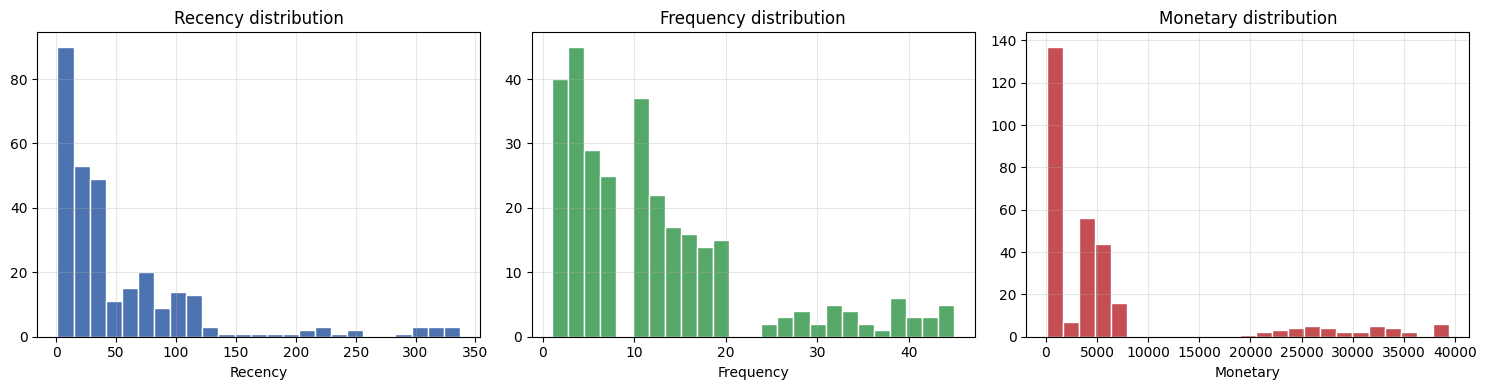

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ['Recency', 'Frequency', 'Monetary'], ['#4C72B0', '#55A868', '#C44E52']):
    ax.hist(rfm[col], bins=25, color=color, edgecolor='white')
    ax.set_title(f'{col} distribution')
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

## 3. Step 2 — Scale Your Features

Recency is measured in days (1–337), Frequency in transaction counts (1–45), Monetary in currency units
(72–39,424). If we clustered on raw values, Monetary would dominate the distance calculation purely
because its numbers are bigger — not because it's more important. We standardize all three features
(zero mean, unit variance) with `StandardScaler` so each contributes on equal footing.

In [6]:
features = ['Recency', 'Frequency', 'Monetary']
X = rfm[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

rfm_scaled = pd.DataFrame(X_scaled, columns=features, index=rfm.index)
print("Mean after scaling (should be ~0):")
print(rfm_scaled.mean().round(3))
print("\nStd after scaling (should be ~1):")
print(rfm_scaled.std().round(3))
rfm_scaled.head()

Mean after scaling (should be ~0):
Recency     -0.0
Frequency   -0.0
Monetary     0.0
dtype: float64

Std after scaling (should be ~1):
Recency      1.002
Frequency    1.002
Monetary     1.002
dtype: float64


,Recency,Frequency,Monetary
0,-0.772792,0.356692,-0.113196
1,-0.464634,0.544920,-0.010898
2,-0.259195,-0.866790,-0.581723
3,-0.728770,2.144859,2.570262
4,-0.420611,0.356692,-0.058397


## 4. Step 3 — Find the Right Number of Clusters

We evaluate `k = 2..10` on two criteria:

- **Elbow method (inertia)** — within-cluster sum of squares. We look for the point where adding more
  clusters stops meaningfully reducing inertia.
- **Silhouette score** — how well-separated and internally cohesive the clusters are (ranges -1 to 1,
  higher is better).

In [7]:
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

results = pd.DataFrame({'k': list(k_range), 'inertia': inertias, 'silhouette': silhouette_scores})
results

,k,inertia,silhouette
0,2,394.208028,0.678910
1,3,183.032138,0.678170
2,4,93.388049,0.570227
3,5,71.407066,0.523155
4,6,50.343627,0.519382
5,7,41.125688,0.462554
6,8,30.223591,0.481482
7,9,24.119083,0.482195
8,10,21.074266,0.476483


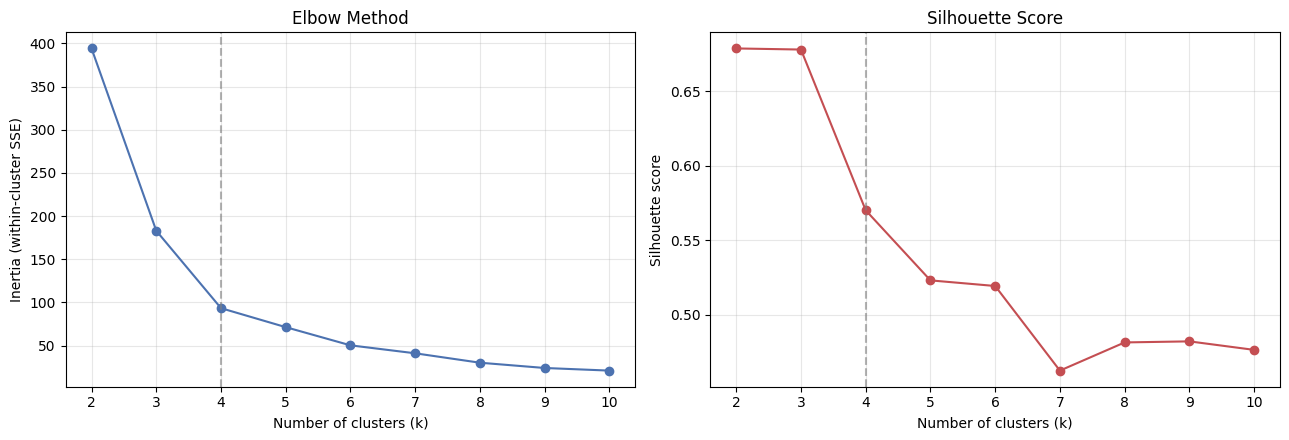

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(k_range, inertias, 'o-', color='#4C72B0')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].set_title('Elbow Method')
axes[0].axvline(4, color='gray', linestyle='--', alpha=0.6)

axes[1].plot(k_range, silhouette_scores, 'o-', color='#C44E52')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette Score')
axes[1].axvline(4, color='gray', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**Reasoning for k:**

- Silhouette score is technically *highest* at k=2 (≈0.68) and almost identical at k=3 (≈0.68), then
  drops to ≈0.57 at k=4 and keeps declining gradually afterward. Mathematically, k=2 or k=3 is the
  "cleanest" split.
- But k=2–3 is not business-actionable here: at k=2 the data essentially splits into "big spenders" vs.
  "everyone else," and at k=3 it separates a tiny high-value group, a large middle group, and a small
  dormant group — with no dedicated segment for recently-active, moderate-spending regulars.
- The elbow plot shows inertia flattening out noticeably after **k=4**: the marginal drop from k=4→5
  is much smaller than the drops from k=2→3→4.
- k=4 still has a solid silhouette score (≈0.57 — well above the ~0.5 threshold generally considered
  "reasonable" structure) and, critically, produces four clusters that map onto genuinely distinct,
  actionable RFM profiles (checked below): a small VIP group, a dormant/churned group, a new/occasional
  low-value group, and a loyal-regular group.

The deciding factor for choosing between k=3 and k=4 is business interpretability, not the single
highest silhouette digit. We proceed with **k = 4**.

## 5. Step 4 — Fit K-Means

In [9]:
k_final = 4
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
rfm['cluster'] = kmeans.fit_predict(X_scaled)

print(f"Final silhouette score at k={k_final}: {silhouette_score(X_scaled, rfm['cluster']):.3f}")
print(f"\nCluster sizes:")
print(rfm['cluster'].value_counts().sort_index())

Final silhouette score at k=4: 0.570

Cluster sizes:
cluster
0    111
1     40
2     21
3    128
Name: count, dtype: int64


In [10]:
cluster_profile = rfm.groupby('cluster')[features].mean().round(1)
cluster_profile['n_customers'] = rfm['cluster'].value_counts().sort_index()
cluster_profile = cluster_profile.sort_values('Monetary', ascending=False)
cluster_profile

,Recency,Frequency,Monetary,n_customers
cluster,,,,
1,8.4,35.0,29683.6,40
3,20.2,13.7,4700.2,128
0,71.6,4.2,752.5,111
2,263.4,2.1,320.5,21


## 6. Step 5 — Visualize with PCA

We reduce the 3 scaled RFM features to 2 principal components purely for visualization — the clustering
itself was done on the full 3D scaled feature space above, not on the PCA output.

In [11]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance ratio: {pca.explained_variance_ratio_.round(3)}")
print(f"Total variance captured by 2 components: {pca.explained_variance_ratio_.sum():.1%}")

rfm['pca1'] = X_pca[:, 0]
rfm['pca2'] = X_pca[:, 1]

Explained variance ratio: [0.75  0.237]
Total variance captured by 2 components: 98.7%


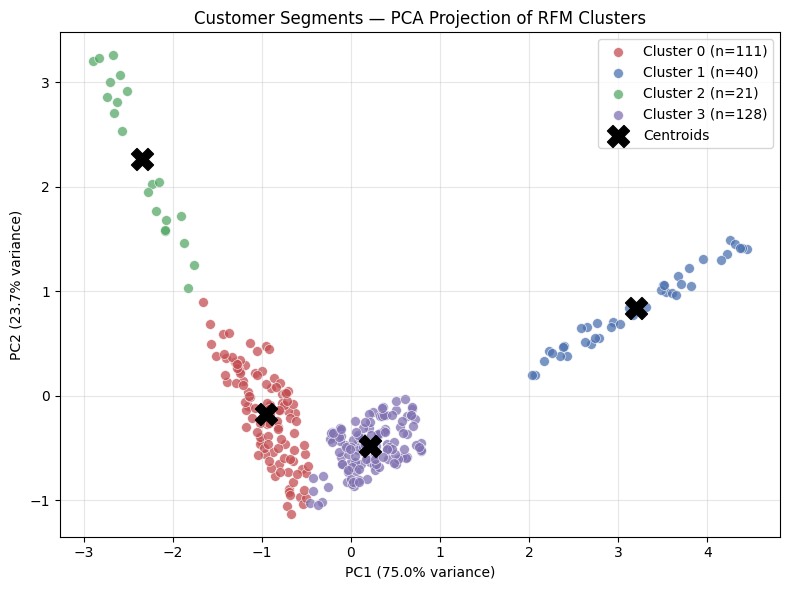

In [12]:
colors = ['#C44E52', '#4C72B0', '#55A868', '#8172B2']
fig, ax = plt.subplots(figsize=(8, 6))

for c in sorted(rfm['cluster'].unique()):
    subset = rfm[rfm['cluster'] == c]
    ax.scatter(subset['pca1'], subset['pca2'], label=f'Cluster {c} (n={len(subset)})',
               color=colors[c % len(colors)], s=50, alpha=0.75, edgecolor='white', linewidth=0.5)

centers_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1], marker='X', s=250, c='black',
           label='Centroids', zorder=5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Customer Segments — PCA Projection of RFM Clusters')
ax.legend()
plt.tight_layout()
plt.show()

The clusters are visually well-separated in the 2D projection, especially the small high-value VIP group and the dormant group, which supports the k=4 choice.

## 7. Persona Summary

The table below restates the cluster averages sorted from highest to lowest value, followed by a descriptive write-up for each persona.

In [13]:
persona_names = {}  # filled in after inspecting cluster_profile below
cluster_profile

,Recency,Frequency,Monetary,n_customers
cluster,,,,
1,8.4,35.0,29683.6,40
3,20.2,13.7,4700.2,128
0,71.6,4.2,752.5,111
2,263.4,2.1,320.5,21


Based on the average Recency / Frequency / Monetary values per cluster:

---

### VIP Customers
**Profile:** Very recent purchases (~8 days), very high frequency (~35 transactions/year), very high
spend (~$29,700/year). Smallest group (~13% of customers).

These are the top-tier, highest-value customers — they buy often and recently, and their total spend
dwarfs every other segment. Losing even one of them has an outsized revenue impact. **Action:** priority
loyalty tier, dedicated account outreach, early access to new products, and retention should be treated
as a top business risk, not a marketing afterthought.

### Loyal / Regular Customers
**Profile:** Recent purchases (~20 days), moderate-high frequency (~14 transactions/year), moderate
spend (~$4,700/year). The second-largest group (~43% of customers).

These are dependable, engaged shoppers — not big spenders individually, but consistent and numerous,
making them a major share of overall revenue. **Action:** nurture toward VIP status with tiered loyalty
incentives, bundle/cross-sell offers, and personalized recommendations based on their purchase history.

### New / Occasional Customers
**Profile:** Moderate recency (~72 days), low frequency (~4 transactions/year), low spend (~$750/year).
The largest group (~37% of customers).

Either genuinely new customers still forming a habit, or occasional/one-off shoppers who haven't been
converted into regulars. **Action:** onboarding email sequences, first-repeat-purchase incentives, and
category-based recommendations to nudge them toward the "Loyal" tier before they go dormant.

### Dormant / At-Risk Customers
**Profile:** Very high recency (~263 days — hasn't bought in nearly 9 months), very low frequency
(~2 transactions/year), lowest spend (~$320/year). Smallest group (~7% of customers).

These customers have effectively churned. **Action:** low-cost win-back campaigns (discount codes,
"we miss you" emails) are worth trying, but given how low their historical spend was even when active,
this group should get the least marketing budget per customer relative to VIPs and Loyal customers.

---

**Business takeaway:** The 300 customers split unevenly by value — a small VIP segment (~13%) likely
drives a disproportionate share of revenue, a Loyal segment (~43%) is the volume backbone of the
business, a large New/Occasional segment (~37%) represents the biggest growth opportunity if converted,
and a small Dormant segment (~7%) is largely a lost cause worth only minimal win-back spend.